In [13]:
!pip install yfinance backtesting

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
from backtesting import Backtest, Strategy
import matplotlib.pyplot as plt

In [15]:
data = yf.download("RELIANCE.NS", period="1y", interval="1h")

data.dropna(inplace=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


/tmp/ipykernel_5525/1084645603.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("RELIANCE.NS", period="1y", interval="1h")
[*********************100%***********************]  1 of 1 completed


In [16]:
def EMA(series, n):
    series = np.array(series, dtype=float)
    alpha  = 2 / (n + 1)
    ema    = np.empty(len(series))
    ema[0] = series[0]

    for i in range(1, len(series)):
        ema[i] = alpha * series[i] + (1 - alpha) * ema[i-1]

    return ema


In [17]:
def RSI(series, n=14):
    series   = np.array(series, dtype=float)
    delta    = np.diff(series, prepend=series[0])

    gain     = np.where(delta > 0, delta, 0.0)
    loss     = np.where(delta < 0, -delta, 0.0)

    avg_gain = np.empty(len(series))
    avg_loss = np.empty(len(series))

    avg_gain[n] = gain[1:n+1].mean()
    avg_loss[n] = loss[1:n+1].mean()

    for i in range(n+1, len(series)):
        avg_gain[i] = (avg_gain[i-1] * (n-1) + gain[i]) / n
        avg_loss[i] = (avg_loss[i-1] * (n-1) + loss[i]) / n

    rs         = np.zeros(len(series))
    rsi        = np.full(len(series), np.nan)
    rs[n:]     = avg_gain[n:] / np.where(avg_loss[n:] == 0, 1e-10, avg_loss[n:])
    rsi[n:]    = 100 - (100 / (1 + rs[n:]))

    return rsi

In [18]:
def ATR(df, n=14):
    high  = np.array(df['High'],  dtype=float)
    low   = np.array(df['Low'],   dtype=float)
    close = np.array(df['Close'], dtype=float)

    prev_close = np.roll(close, 1)
    prev_close[0] = close[0]

    tr  = np.maximum(high - low,
          np.maximum(np.abs(high - prev_close),
                     np.abs(low  - prev_close)))

    atr = np.full(len(tr), np.nan)
    atr[n] = tr[1:n+1].mean()

    for i in range(n+1, len(tr)):
        atr[i] = (atr[i-1] * (n-1) + tr[i]) / n

    return atr

In [19]:
class EMARSIATRStrategy(Strategy):

    rsi_threshold = 42
    rsi_window    = 7
    sl_multiplier = 2.0
    ema_lookback  = 10

    def init(self):
        close    = self.data.Close
        self.ema = self.I(EMA, close, 50)
        self.rsi = self.I(RSI, close, 14)
        self.atr = self.I(ATR, self.data.df, 14)

    def next(self):
        price = self.data.Close[-1]
        atr   = self.atr[-1]
        rsi   = self.rsi[-1]

        if np.isnan(self.ema[-1]) or np.isnan(rsi) or np.isnan(atr):
            return

        big_trend_up   = self.ema[-1] > self.ema[-self.ema_lookback]
        big_trend_down = self.ema[-1] < self.ema[-self.ema_lookback]

        rsi_recovered = any(
            self.rsi[-k-1] < self.rsi_threshold and self.rsi[-k]   > self.rsi_threshold
            for k in range(1, self.rsi_window + 1)
        )
        rsi_faded = any(
            self.rsi[-k-1] > (100 - self.rsi_threshold) and self.rsi[-k]   < (100 - self.rsi_threshold)
            for k in range(1, self.rsi_window + 1)
        )

        if big_trend_up and rsi_recovered and not self.position:
            sl = price - self.sl_multiplier * atr
            tp = price + 2 * (price - sl)
            self.buy(sl=sl, tp=tp)

        elif big_trend_down and rsi_faded and not self.position:
            sl = price + self.sl_multiplier * atr
            tp = price - 2 * (sl - price)
            self.sell(sl=sl, tp=tp)


bt_opt = Backtest(
    data,
    EMARSIATRStrategy,
    cash             = 100000,
    commission       = 0.0005,
    exclusive_orders = True,
    finalize_trades  = True
)

stats = bt_opt.run()

print(stats)



Backtest.run:   0%|          | 0/1693 [00:00<?, ?bar/s]

Start                     2025-04-01 03:45...
End                       2026-03-30 07:45...
Duration                    363 days 04:00:00
Exposure Time [%]                    22.65808
Equity Final [$]                 112809.27939
Equity Peak [$]                  116228.28547
Commissions [$]                    2504.15497
Return [%]                           12.80928
Buy & Hold Return [%]                 7.95842
Return (Ann.) [%]                    13.19843
Volatility (Ann.) [%]                 9.35576
CAGR [%]                              8.72311
Sharpe Ratio                          1.41073
Sortino Ratio                         3.02503
Calmar Ratio                          2.75666
Alpha [%]                            12.92069
Beta                                   -0.014
Max. Drawdown [%]                    -4.78783
Avg. Drawdown [%]                    -1.10844
Max. Drawdown Duration      112 days 00:00:00
Avg. Drawdown Duration       12 days 01:00:00
# Trades                          

In [20]:
opt_stats = bt_opt.optimize(
    rsi_threshold  = [35, 38, 40, 42, 45],
    rsi_window     = [ 5, 7, 9],
    sl_multiplier  = [ 2.0, 2.5],
    ema_lookback   = [ 5,10,15],
    maximize       = 'Sharpe Ratio',
)

print(f"  rsi_threshold : {opt_stats._strategy.rsi_threshold}")
print(f"  rsi_window    : {opt_stats._strategy.rsi_window}")
print(f"  sl_multiplier : {opt_stats._strategy.sl_multiplier}")
print(f"  ema_lookback  : {opt_stats._strategy.ema_lookback}")

Backtest.optimize:   0%|          | 0/90 [00:00<?, ?it/s]

Process ForkPoolWorker-3:


KeyboardInterrupt: 

In [29]:
initial_cash = 100000
commission = 0.0005
rsi_threshold = 42
rsi_window = 7
sl_multiplier = 2.0
ema_lookback = 10

close_vals = data['Close'].values
open_vals = data['Open'].values
high_vals = data['High'].values
low_vals = data['Low'].values

ema_series = EMA(close_vals, 50)
rsi_series = RSI(close_vals, 14)
atr_series = ATR(data, 14)

cash = initial_cash
position = 0
entry_price = 0
units = 0
sl, tp = 0, 0
equity_curve = []
trade_log = []

for i in range(len(data)):
    if i < 50 or np.isnan(rsi_series[i]) or np.isnan(atr_series[i]):
        equity_curve.append(cash)
        continue

    curr_high = high_vals[i]
    curr_low = low_vals[i]
    curr_close = close_vals[i]

    if position != 0:
        hit_exit = False
        exit_price = 0

        if position == 1:
            if curr_low <= sl:
                exit_price = sl
                hit_exit = True
            elif curr_high >= tp:
                exit_price = tp
                hit_exit = True

            if hit_exit:
                cash = (units * exit_price) * (1 - commission)
                trade_log.append((exit_price / entry_price) - 1)
                position = 0
                units = 0

        elif position == -1:
            if curr_high >= sl:
                exit_price = sl
                hit_exit = True
            elif curr_low <= tp:
                exit_price = tp
                hit_exit = True

            if hit_exit:
                diff = (entry_price - exit_price)
                cash = (units * entry_price + (units * diff)) * (1 - commission)
                trade_log.append((entry_price / exit_price) - 1)
                position = 0
                units = 0

    if position == 0 and i + 1 < len(data):
        trend_up = ema_series[i] > ema_series[i - ema_lookback]
        trend_down = ema_series[i] < ema_series[i - ema_lookback]
        rsi_rec = any(rsi_series[i-k-1] < rsi_threshold and rsi_series[i-k] > rsi_threshold for k in range(rsi_window))
        rsi_fad = any(rsi_series[i-k-1] > (100-rsi_threshold) and rsi_series[i-k] < (100-rsi_threshold) for k in range(rsi_window))

        next_open = open_vals[i+1]

        if trend_up and rsi_rec:
            position = 1
            entry_price = next_open
            units = (cash * (1 - commission)) / entry_price
            cash = 0
            sl = entry_price - sl_multiplier * atr_series[i]
            tp = entry_price + 2 * (entry_price - sl)

        elif trend_down and rsi_fad:
            position = -1
            entry_price = next_open
            units = (cash * (1 - commission)) / entry_price
            cash = 0
            sl = entry_price + sl_multiplier * atr_series[i]
            tp = entry_price - 2 * (sl - entry_price)

    if position == 1:
        current_val = units * curr_close
    elif position == -1:
        diff = (entry_price - curr_close)
        current_val = (units * entry_price) + (units * diff)
    else:
        current_val = cash
    equity_curve.append(current_val)

total return: 10.504038086181332 %
annualized return: 10.564866672496898 %
max drawdown: -6.154719522317451 %
sharpe ratio: 1.2858216083723062
win rate: 50.0 %
number of trades: 22


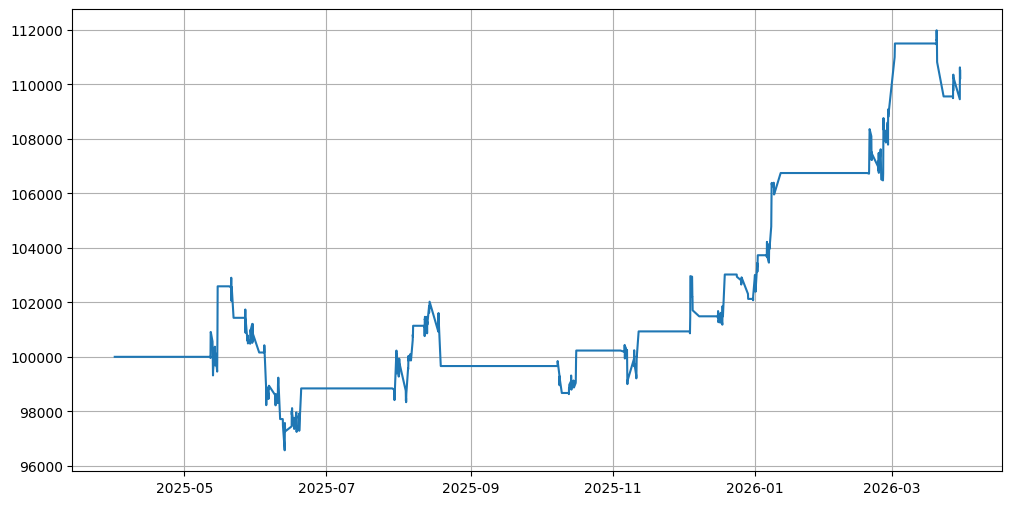

In [36]:
equity_curve = np.array(equity_curve)
total_ret = (equity_curve[-1] - initial_cash) / initial_cash

days = (data.index[-1] - data.index[0]).days
ann_ret = (1 + total_ret)**(365/days) - 1

peak = np.maximum.accumulate(equity_curve)
drawdown = (equity_curve - peak) / peak
max_dd = drawdown.min()

num_trades = len(trade_log)
wins = [r for r in trade_log if r > 0]
num_wins = len(wins)
win_rate = num_wins / num_trades

returns_pct = pd.Series(equity_curve).pct_change().dropna()
sharpe = (returns_pct.mean() / returns_pct.std()) * np.sqrt(252 * 7)


print(f"total return: {total_ret*100} %")
print(f"annualized return: {ann_ret*100} %")
print(f"max drawdown: {max_dd*100} %")
print(f"sharpe ratio: {sharpe}")
print(f"win rate: {win_rate*100} %")
print(f"number of trades: {len(trade_log)}")

plt.figure(figsize=(12, 6))
plt.plot(data.index, equity_curve)
plt.grid(True)
plt.show()